:Roll Number: CH.SC.U4CSE24123
Name: M.A.KAUSHIK
LOGISTIC REGRESSION 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
url = "https://www.kaggle.com/datasets/ayushsvast/online-shopping-behaviour"

In [ ]:
df = pd.read_excel("online_shopping_behavior.xlsx")
print(df.head())

  User ID Age Group  Gender Preferred Shopping Website  \
0   U5094     19-30    Male                   Flipkart   
1   U8120     31-50  Female                     Amazon   
2   U3109     31-50  Female                     Amazon   
3   U4747     31-50    Male                     Amazon   
4   U2862     19-30  Female                     Myntra   

  Average Monthly Spend (INR) Device Used    Payment Method  \
0                   1000-5000      Laptop  Cash on Delivery   
1                  5000-10000      Laptop               UPI   
2                  5000-10000      Tablet  Cash on Delivery   
3                      10000+      Laptop               UPI   
4                  5000-10000      Laptop  Cash on Delivery   

  Purchase Frequency Return Rate (%) Most Purchased Category  
0              Daily             30%             Electronics  
1              Daily             30%               Groceries  
2             Weekly             30%                Clothing  
3             Weekly

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nDataset information:")
print(df.info())

Shape: (999, 10)

Columns:
Index(['User ID', 'Age Group', 'Gender', 'Preferred Shopping Website',
       'Average Monthly Spend (INR)', 'Device Used', 'Payment Method',
       'Purchase Frequency', 'Return Rate (%)', 'Most Purchased Category'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   User ID                      999 non-null    str  
 1   Age Group                    999 non-null    str  
 2   Gender                       999 non-null    str  
 3   Preferred Shopping Website   999 non-null    str  
 4   Average Monthly Spend (INR)  999 non-null    str  
 5   Device Used                  999 non-null    str  
 6   Payment Method               999 non-null    str  
 7   Purchase Frequency           999 non-null    str  
 8   Return Rate (%)              999 non-null    str  
 9  

In [ ]:
print(df.describe(include="all"))

       User ID Age Group  Gender Preferred Shopping Website  \
count      999       999     999                        999   
unique     950         3       2                          3   
top      U9234      0-18  Female                     Myntra   
freq         2       352     530                        361   

       Average Monthly Spend (INR) Device Used Payment Method  \
count                          999         999            999   
unique                           3           3              3   
top                         10000+      Laptop    Credit Card   
freq                           346         339            343   

       Purchase Frequency Return Rate (%) Most Purchased Category  
count                 999             999                     999  
unique                  3               3                       3  
top                Weekly             30%                Clothing  
freq                  346             339                     346  


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
User ID                        0
Age Group                      0
Gender                         0
Preferred Shopping Website     0
Average Monthly Spend (INR)    0
Device Used                    0
Payment Method                 0
Purchase Frequency             0
Return Rate (%)                0
Most Purchased Category        0
dtype: int64


In [ ]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].value_counts())


 User ID
User ID
U9234    2
U2886    2
U3002    2
U3262    2
U5321    2
        ..
U3034    1
U7258    1
U2853    1
U4409    1
U6128    1
Name: count, Length: 950, dtype: int64

 Age Group
Age Group
0-18     352
31-50    327
19-30    320
Name: count, dtype: int64

 Gender
Gender
Female    530
Male      469
Name: count, dtype: int64

 Preferred Shopping Website
Preferred Shopping Website
Myntra      361
Flipkart    321
Amazon      317
Name: count, dtype: int64

 Average Monthly Spend (INR)
Average Monthly Spend (INR)
10000+        346
1000-5000     331
5000-10000    322
Name: count, dtype: int64

 Device Used
Device Used
Laptop    339
Mobile    335
Tablet    325
Name: count, dtype: int64

 Payment Method
Payment Method
Credit Card         343
Cash on Delivery    329
UPI                 327
Name: count, dtype: int64

 Purchase Frequency
Purchase Frequency
Weekly     346
Daily      329
Monthly    324
Name: count, dtype: int64

 Return Rate (%)
Return Rate (%)
30%    339
20%    334
10%   

C:\Users\Rocki\AppData\Local\Temp\ipykernel_28284\3152860343.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


In [ ]:
df = df.dropna()
print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (999, 10)


In [ ]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)
print(df_encoded.head())
print("Encoded shape:", df_encoded.shape)

   User ID_U1020  User ID_U1047  User ID_U1058  User ID_U1064  User ID_U1080  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   User ID_U1088  User ID_U1089  User ID_U1094  User ID_U1107  User ID_U1109  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   ...  Device Used_Mobile  Device Use

In [ ]:
print(df.columns.tolist())

['User ID', 'Age Group', 'Gender', 'Preferred Shopping Website', 'Average Monthly Spend (INR)', 'Device Used', 'Payment Method', 'Purchase Frequency', 'Return Rate (%)', 'Most Purchased Category']


In [ ]:
X = df_encoded.drop(
    columns=["Most Purchased Category"],
    errors="ignore"
)
y = df["Most Purchased Category"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (999, 966)
y shape: (999,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print("Target classes:")
print(label_encoder.classes_)

Target classes:
['Clothing' 'Electronics' 'Groceries']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (799, 966)
Testing data: (200, 966)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standardization completed")

Standardization completed


In [ ]:
model = LogisticRegression(
    max_iter=1000
)
model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [ ]:
y_pred = model.predict(X_test_scaled)
print("Predictions:")
print(y_pred[:20])

Predictions:
[1 1 0 1 1 0 2 0 1 1 0 2 0 0 2 0 0 0 2 2]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.975
Accuracy percentage: 97.5 %


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67  0  2]
 [ 2 65  0]
 [ 1  0 63]]


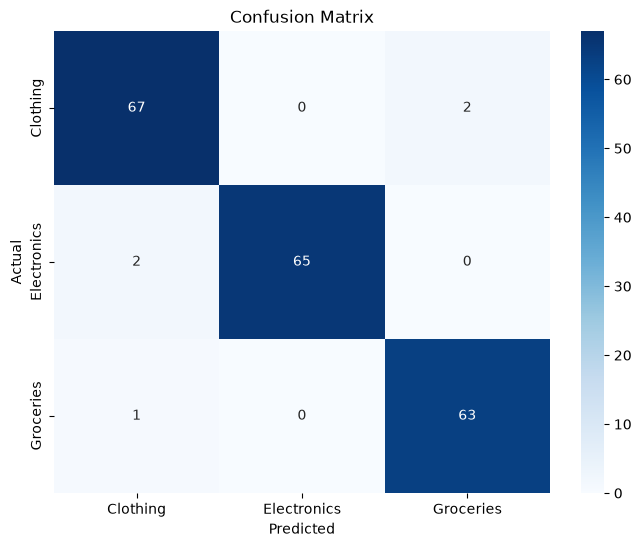

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    Clothing       0.96      0.97      0.96        69
 Electronics       1.00      0.97      0.98        67
   Groceries       0.97      0.98      0.98        64

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.97      0.98       200



In [ ]:
probabilities = model.predict_proba(X_test_scaled)
print("Prediction probabilities for first 5 customers:\n")
for i in range(5):
    print("Customer", i + 1)
    for class_name, probability in zip(
        label_encoder.classes_,
        probabilities[i]
    ):
        print(
            class_name,
            ":",
            round(probability * 100, 2),
            "%"
        )
    print()

Prediction probabilities for first 5 customers:

Customer 1
Clothing : 2.64 %
Electronics : 96.91 %
Groceries : 0.44 %

Customer 2
Clothing : 1.74 %
Electronics : 97.66 %
Groceries : 0.61 %

Customer 3
Clothing : 92.07 %
Electronics : 3.93 %
Groceries : 3.99 %

Customer 4
Clothing : 4.76 %
Electronics : 94.18 %
Groceries : 1.06 %

Customer 5
Clothing : 3.56 %
Electronics : 95.65 %
Groceries : 0.79 %



In [ ]:
predicted_class = model.predict(X_test_scaled)
for i in range(5):
    product = label_encoder.inverse_transform(
        [predicted_class[i]]
    )[0]
    print(
        "Customer",
        i + 1,
        "is most likely to buy:",
        product
    )

Customer 1 is most likely to buy: Electronics
Customer 2 is most likely to buy: Electronics
Customer 3 is most likely to buy: Clothing
Customer 4 is most likely to buy: Electronics
Customer 5 is most likely to buy: Electronics
